In [1]:
# Cell 1: Imports and Initial Setup
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import warnings
import matplotlib
matplotlib.use('Agg')  # Use a non-interactive backend
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Define JOB_ID
JOB_ID = "01"

print("Imports and setup complete.")

Imports and setup complete.


In [2]:
# Cell 2: Set scvelo Settings
scv.settings.verbosity = 3  # Show errors and warnings
scv.set_figure_params('scvelo')

print("scvelo settings configured.")

scvelo settings configured.


In [2]:
# Cell 3: Define Paths
print("Defining paths...")

# Base paths
data_base_path = "/storage/liuxiaodongLab/jiangjing/Projects/YutingFu/PD_YutingFu/scvelo/data"
plots_base_path = "/storage/liuxiaodongLab/jiangjing/Projects/YutingFu/PD_YutingFu/scvelo/plot"

# Ensure the plots directory exists
os.makedirs(plots_base_path, exist_ok=True)

# File paths
velocyto_file = os.path.join(data_base_path, 'merged.loom')
clusters_file = os.path.join(data_base_path, "cell_clusters.csv")
umap_file = os.path.join(data_base_path, "cell_embeddings.csv")
path_10x = os.path.join(data_base_path, "filtered_feature_bc_matrix")

# Check if files exist
required_files = [clusters_file, umap_file, path_10x, velocyto_file]
for f in required_files:
    if not os.path.exists(f):
        print(f"Missing required file: {f}")
        raise FileNotFoundError(f"Missing data file: {f}")

print("All required files found.")

Defining paths...
All required files found.


In [33]:
# Cell 4: Read Clusters
print("Reading clusters file...")
Clusters_Loupe = pd.read_csv(clusters_file, delimiter=',',index_col=0)
Barcodes = Clusters_Loupe.index

# Quick check
Clusters_Loupe

Reading clusters file...


,human_celltypes_250418
rat12M_A_CELL202_N1,Immature DA
rat12M_A_CELL284_N3,DA progenitor-CHRNB3 high
rat12M_A_CELL418_N2,DA progenitor-CHRNB3 high
rat12M_A_CELL494_N2,DA progenitor-CHRNB3 high
rat12M_A_CELL678_N1,Immature DA
...,...
P1B_CAGCGTGCACTGCATA-1,DA progenitor-terminal
P1B_GAAATGAGTTGTCATG-1,Rgl1-like
P1B_ATCAGGTCATTGCAGT-1,DA progenitor-FABP7
P1B_CTCATTAAGCATTTAC-1,DA progenitor-FABP7


In [34]:
# Read UMAP exported from Loupe Browser 
UMAP_Loupe = pd.read_csv(umap_file, delimiter=',',index_col=0)


In [35]:
UMAP_Loupe

,UMAP_1,UMAP_2
rat12M_A_CELL202_N1,5.924265,1.167760
rat12M_A_CELL284_N3,7.714844,3.922689
rat12M_A_CELL418_N2,9.711450,1.759684
rat12M_A_CELL494_N2,7.515412,3.406879
rat12M_A_CELL678_N1,5.685509,1.899676
...,...,...
P1B_CAGCGTGCACTGCATA-1,8.466014,1.218162
P1B_GAAATGAGTTGTCATG-1,8.615372,10.515175
P1B_ATCAGGTCATTGCAGT-1,9.879086,9.479380
P1B_CTCATTAAGCATTTAC-1,11.326687,9.530545


In [36]:
# Tansform to Numpy (for formatting)
UMAP_Loupe = UMAP_Loupe.to_numpy()

In [37]:
# Cell 6: Read 10X Data
print("Reading 10X data...")
Sample3p = sc.read_10x_mtx(path_10x, var_names='gene_symbols')
print(f"Total number of cells in 10X data: {Sample3p.shape[0]}")


Reading 10X data...
Total number of cells in 10X data: 11032


In [38]:
Sample3p_df = Sample3p.to_df()
Sample3p_df.head()

,DDX11L2,MIR1302-2HG,LINC01409,FAM87B,LINC00115,LINC01128,FAM41C,LINC02593,SAMD11,NOC2L,...,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,MAFIP
rat12M_A_CELL202_N1,0.0,0.0,0.0,0.0,0.000000,0.661746,0.0,0.0,0.000000,1.056522,...,0.0,0.000000,1.056522,0.000000,0.0,0.661746,0.000000,0.0,0.000000,0.0
rat12M_A_CELL284_N3,0.0,0.0,0.0,0.0,0.000000,0.845448,0.0,0.0,0.366729,0.000000,...,0.0,1.411243,2.034066,0.366729,0.0,1.770379,0.366729,0.0,1.770379,0.0
rat12M_A_CELL418_N2,0.0,0.0,0.0,0.0,0.000000,0.390111,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.390111,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
rat12M_A_CELL494_N2,0.0,0.0,0.0,0.0,0.399894,0.399894,0.0,0.0,0.000000,0.399894,...,0.0,0.399894,0.906240,0.000000,0.0,0.906240,0.000000,0.0,0.684779,0.0
rat12M_A_CELL678_N1,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.678190,...,0.0,0.000000,0.395519,0.000000,0.0,0.395519,0.000000,0.0,0.000000,0.0


In [39]:
Sample3p = Sample3p[Barcodes]

In [40]:
Sample3p

View of AnnData object with n_obs × n_vars = 11032 × 24190
    var: 'gene_ids', 'feature_types'

In [41]:
# Add Clusters from Loupe to object
Sample3p.obs['Loupe'] = Clusters_Loupe

# Add UMAP from Loupe to object
Sample3p.obsm["X_umap"] = UMAP_Loupe

In [42]:
# Read velocyto output
VelNeutro3p = sc.read(velocyto_file)

In [43]:
VelNeutro3p.obs

,batch,data_source,obs_names
0,P1A,adata1,P1A_AAACGCTTCTCGGTCT-1
1,P1A,adata1,P1A_AAACCCAAGACAAGCC-1
2,P1A,adata1,P1A_AAACGAACACATCCCT-1
3,P1A,adata1,P1A_AAACGCTCACTCGATA-1
4,P1A,adata1,P1A_AAACGCTTCGGTCTAA-1
...,...,...,...
598510,rat8M_F,adata2,rat8M_F_CELL17004_N1
598511,rat8M_F,adata2,rat8M_F_CELL17005_N1
598512,rat8M_F,adata2,rat8M_F_CELL17006_N1
598513,rat8M_F,adata2,rat8M_F_CELL17007_N1


In [44]:
VelNeutro3p.var = VelNeutro3p.var.set_index("var_names")
VelNeutro3p.obs = VelNeutro3p.obs.set_index("obs_names")

# Step 2: 清理索引名称（可选）
VelNeutro3p.var_names.name = None
VelNeutro3p.obs_names.name = None

# Step 3: 处理重复项（如有需要）
VelNeutro3p.var_names_make_unique()
VelNeutro3p.obs_names_make_unique()

In [81]:
# 获取 Sample3p 中前缀为 'P1A' 的 barcodes
p1a_barcodes_sample3p = [barcode for barcode in Sample3p.obs_names if barcode.startswith('rat8M_F')]

# 打印数量和前10个 barcodes
print(f"Sample3p 中 P1A barcodes 数量: {len(p1a_barcodes_sample3p)}")
print("Sample3p 前10个 P1A barcodes:", p1a_barcodes_sample3p[:10])

Sample3p 中 P1A barcodes 数量: 159
Sample3p 前10个 P1A barcodes: ['rat8M_F_CELL105_N3', 'rat8M_F_CELL157_N3', 'rat8M_F_CELL519_N2', 'rat8M_F_CELL590_N2', 'rat8M_F_CELL594_N2', 'rat8M_F_CELL668_N2', 'rat8M_F_CELL716_N3', 'rat8M_F_CELL730_N2', 'rat8M_F_CELL753_N2', 'rat8M_F_CELL818_N1']


In [82]:
# 获取 VelNeutro3p 中前缀为 'P1A' 的 barcodes
p1a_barcodes_velocyto = [barcode for barcode in VelNeutro3p.obs_names if barcode.startswith('P1B')]

# 打印数量和前10个 barcodes
print(f"VelNeutro3p 中 P1A barcodes 数量: {len(p1a_barcodes_velocyto)}")
print("VelNeutro3p 前10个 P1A barcodes:", p1a_barcodes_velocyto[:10])

VelNeutro3p 中 P1A barcodes 数量: 17007
VelNeutro3p 前10个 P1A barcodes: ['rat8M_F_CELL1_N1', 'rat8M_F_CELL2_N1', 'rat8M_F_CELL3_N1', 'rat8M_F_CELL4_N1', 'rat8M_F_CELL5_N1', 'rat8M_F_CELL6_N1', 'rat8M_F_CELL7_N1', 'rat8M_F_CELL8_N1', 'rat8M_F_CELL9_N3', 'rat8M_F_CELL10_N1']


In [83]:
# 计算共有的 P1A barcodes
common_p1a_barcodes = set(p1a_barcodes_sample3p) & set(p1a_barcodes_velocyto)

# 打印重叠数量和前10个共有的 barcodes
print(f"共有的 P1A barcodes 数量: {len(common_p1a_barcodes)}")
print("前10个共有的 P1A barcodes:", list(common_p1a_barcodes)[:10])

共有的 P1A barcodes 数量: 159
前10个共有的 P1A barcodes: ['rat8M_F_CELL11262_N1', 'rat8M_F_CELL1039_N2', 'rat8M_F_CELL9921_N1', 'rat8M_F_CELL2563_N3', 'rat8M_F_CELL15268_N1', 'rat8M_F_CELL4439_N1', 'rat8M_F_CELL7866_N2', 'rat8M_F_CELL730_N2', 'rat8M_F_CELL10396_N1', 'rat8M_F_CELL4050_N2']


In [46]:
Sample3p_union = scv.utils.merge(Sample3p, VelNeutro3p)

In [72]:
Sample3p_union.obs

,Loupe,batch,data_source,initial_size_unspliced,initial_size_spliced,initial_size
rat12M_A_CELL202_N1,Immature DA,rat12M_A,adata2,3403.603715,1932.657144,1932.657349
rat12M_A_CELL284_N3,DA progenitor-CHRNB3 high,rat12M_A,adata2,3431.542040,1920.073715,1920.073730
rat12M_A_CELL418_N2,DA progenitor-CHRNB3 high,rat12M_A,adata2,3418.410596,1898.120135,1898.120117
rat12M_A_CELL494_N2,DA progenitor-CHRNB3 high,rat12M_A,adata2,3385.377904,1875.836486,1875.836670
rat12M_A_CELL678_N1,Immature DA,rat12M_A,adata2,3431.272175,1937.769425,1937.769531
...,...,...,...,...,...,...
P1B_TAATTCCAGCTGAAGC-1,DA progenitor-terminal,P1B,adata1,4064.000000,4921.000000,4921.000000
P1B_AATCGACGTGCGGTAA-1,DA progenitor-FABP7,P1B,adata1,3226.000000,2029.000000,2029.000000
P1B_TCACACCTCGGCTTCT-1,DA progenitor-FABP7,P1B,adata1,6697.000000,6621.000000,6621.000000
P1B_TTCCACGCATAATCCG-1,DA progenitor-terminal,P1B,adata1,5107.000000,4929.000000,4929.000000


In [30]:
Sample3p_union.layers['spliced']

<20445x14251 sparse matrix of type '<class 'numpy.float64'>'
	with 34633525 stored elements in Compressed Sparse Row format>

In [ ]:
# Loop over different n_top_genes values
    for n_top_genes in range(500, 10001, 500):
        print(f"\nProcessing with n_top_genes = {n_top_genes}...")
        
        # Create a copy of the data to avoid overwriting
        Sample3p_union_tmp = Sample3p_union.copy()

        # Process data with scvelo
        print("Processing data with scvelo...")
        scv.pp.filter_and_normalize(Sample3p_union_tmp, min_shared_counts=10, n_top_genes=n_top_genes)
        scv.pp.moments(Sample3p_union_tmp, n_pcs=30, n_neighbors=30)

        # Compute velocities
        print("Computing velocities...")
        scv.tl.recover_dynamics(Sample3p_union_tmp, n_jobs=-1)
        scv.tl.velocity(Sample3p_union_tmp, mode='dynamical')
        scv.tl.velocity_graph(Sample3p_union_tmp, n_jobs=-1)
        scv.tl.recover_latent_time(Sample3p_union_tmp)

        # Define the save path for the plot
        plot_filename = f"RNA_velocity_n_top_genes_{n_top_genes}.png"
        plot_save_path = os.path.join(plots_base_path, plot_filename)

        # Generate and save plot
        if 'Loupe' in Sample3p_union_tmp.obs.columns:
            print(f"Generating and saving plot with n_top_genes = {n_top_genes}...")
            scv.pl.velocity_embedding_stream(
                Sample3p_union_tmp,
                basis='X_umap',
                color='Loupe',
                fontsize=20,
                legend_fontsize=20,
                min_mass=2,
                save=plot_save_path,  # Provide the full path here
                show=False  # Ensure the plot is not displayed interactively
            )
        else:
            print("Warning: 'Loupe' not found in Sample3p_union_tmp.obs. Skipping plot for Loupe color.")

        print(f"Plot saved to {plot_save_path}")

In [31]:
# Cell 13: Process Data with scvelo
print("Processing data with scvelo...")
scv.pp.filter_and_normalize(Sample3p_union, min_shared_counts=5) #, n_top_genes=2000
scv.pp.moments(Sample3p_union, n_pcs=30, n_neighbors=30)

print("Data processed.")

Processing data with scvelo...
Filtered out 1231 genes that are detected 5 counts (shared).
Normalized count data: X.
Logarithmized X.


/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_346642/2290793539.py:4: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(Sample3p_union, n_pcs=30, n_neighbors=30)
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 

computing neighbors
    finished (0:00:34) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:33) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
Data processed.


In [ ]:
# Cell 14: Compute Velocities
print("Computing velocities...")
scv.tl.recover_dynamics(Sample3p_union, n_jobs=-1)
scv.tl.velocity(Sample3p_union, mode='dynamical')
scv.tl.velocity_graph(Sample3p_union, n_jobs=-1)
scv.tl.recover_latent_time(Sample3p_union)

print("Velocities computed.")

In [39]:
Sample3p_union.write("velocity_results.h5ad")

Index(['Loupe', 'batch', 'initial_size_unspliced', 'initial_size_spliced',
       'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells',
       'end_points', 'velocity_pseudotime', 'latent_time'],
      dtype='object')

In [8]:
Sample3p_union = sc.read_h5ad("velocity_results_1.h5ad")

computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


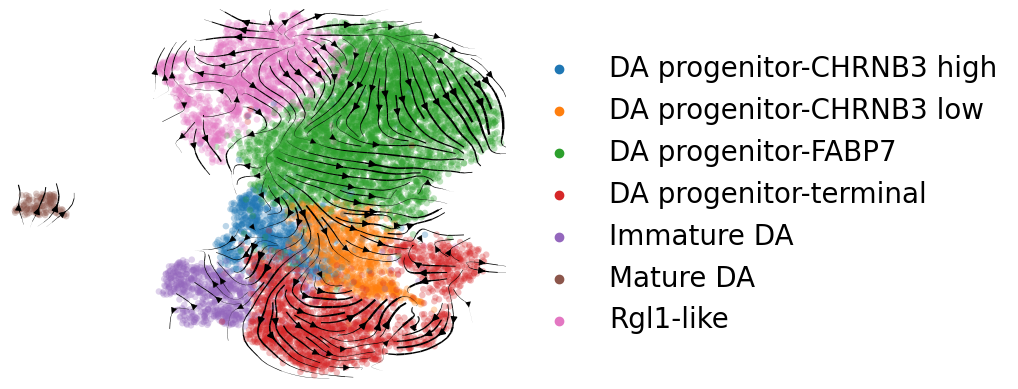

In [9]:
#Stream plot of velocities on the embedding
%matplotlib inline
scv.pl.velocity_embedding_stream(
    Sample3p_union, 
    basis="X_umap",          # 基于 UMAP 降维结果绘制
    color="Loupe",         # 按聚类标签（Loupe 分组）着色
    title='',   # 标题
    legend_loc="right",
    fontsize=20,           # 轴标签字体大小
    legend_fontsize=20,    # 图例字体大小
    min_mass=0,
    density=2,
    arrow_size=1,
    #color_map="Set1",
    #outline_width=(20,20),
    show=True)

In [11]:
# Cell 15: Generate and Save Plot
plot_filename = f"RNA_velocity_03.png"  # Add JOB_ID as suffix
plot_save_path = os.path.join(plots_base_path, plot_filename)
scv.pl.velocity_embedding_stream(
        Sample3p_union,
        basis='X_umap',
        color='Loupe',
        fontsize=20,
        title='',
        legend_fontsize=20,
        legend_loc="right",
        min_mass=2,
        save=plot_save_path,
        show=False
)

saving figure to file /storage/liuxiaodongLab/jiangjing/Projects/YutingFu/PD_YutingFu/scvelo/plot/RNA_velocity_03.png


<Axes: >